In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Fri Aug 15 11:01:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:19:00.0 Off |                  Off |
| 41%   68C    P8             43W /  450W |      11MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  33%|███▎      | 1/3 [00:00<00:00,  7.95it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline co

IndexError: list index out of range

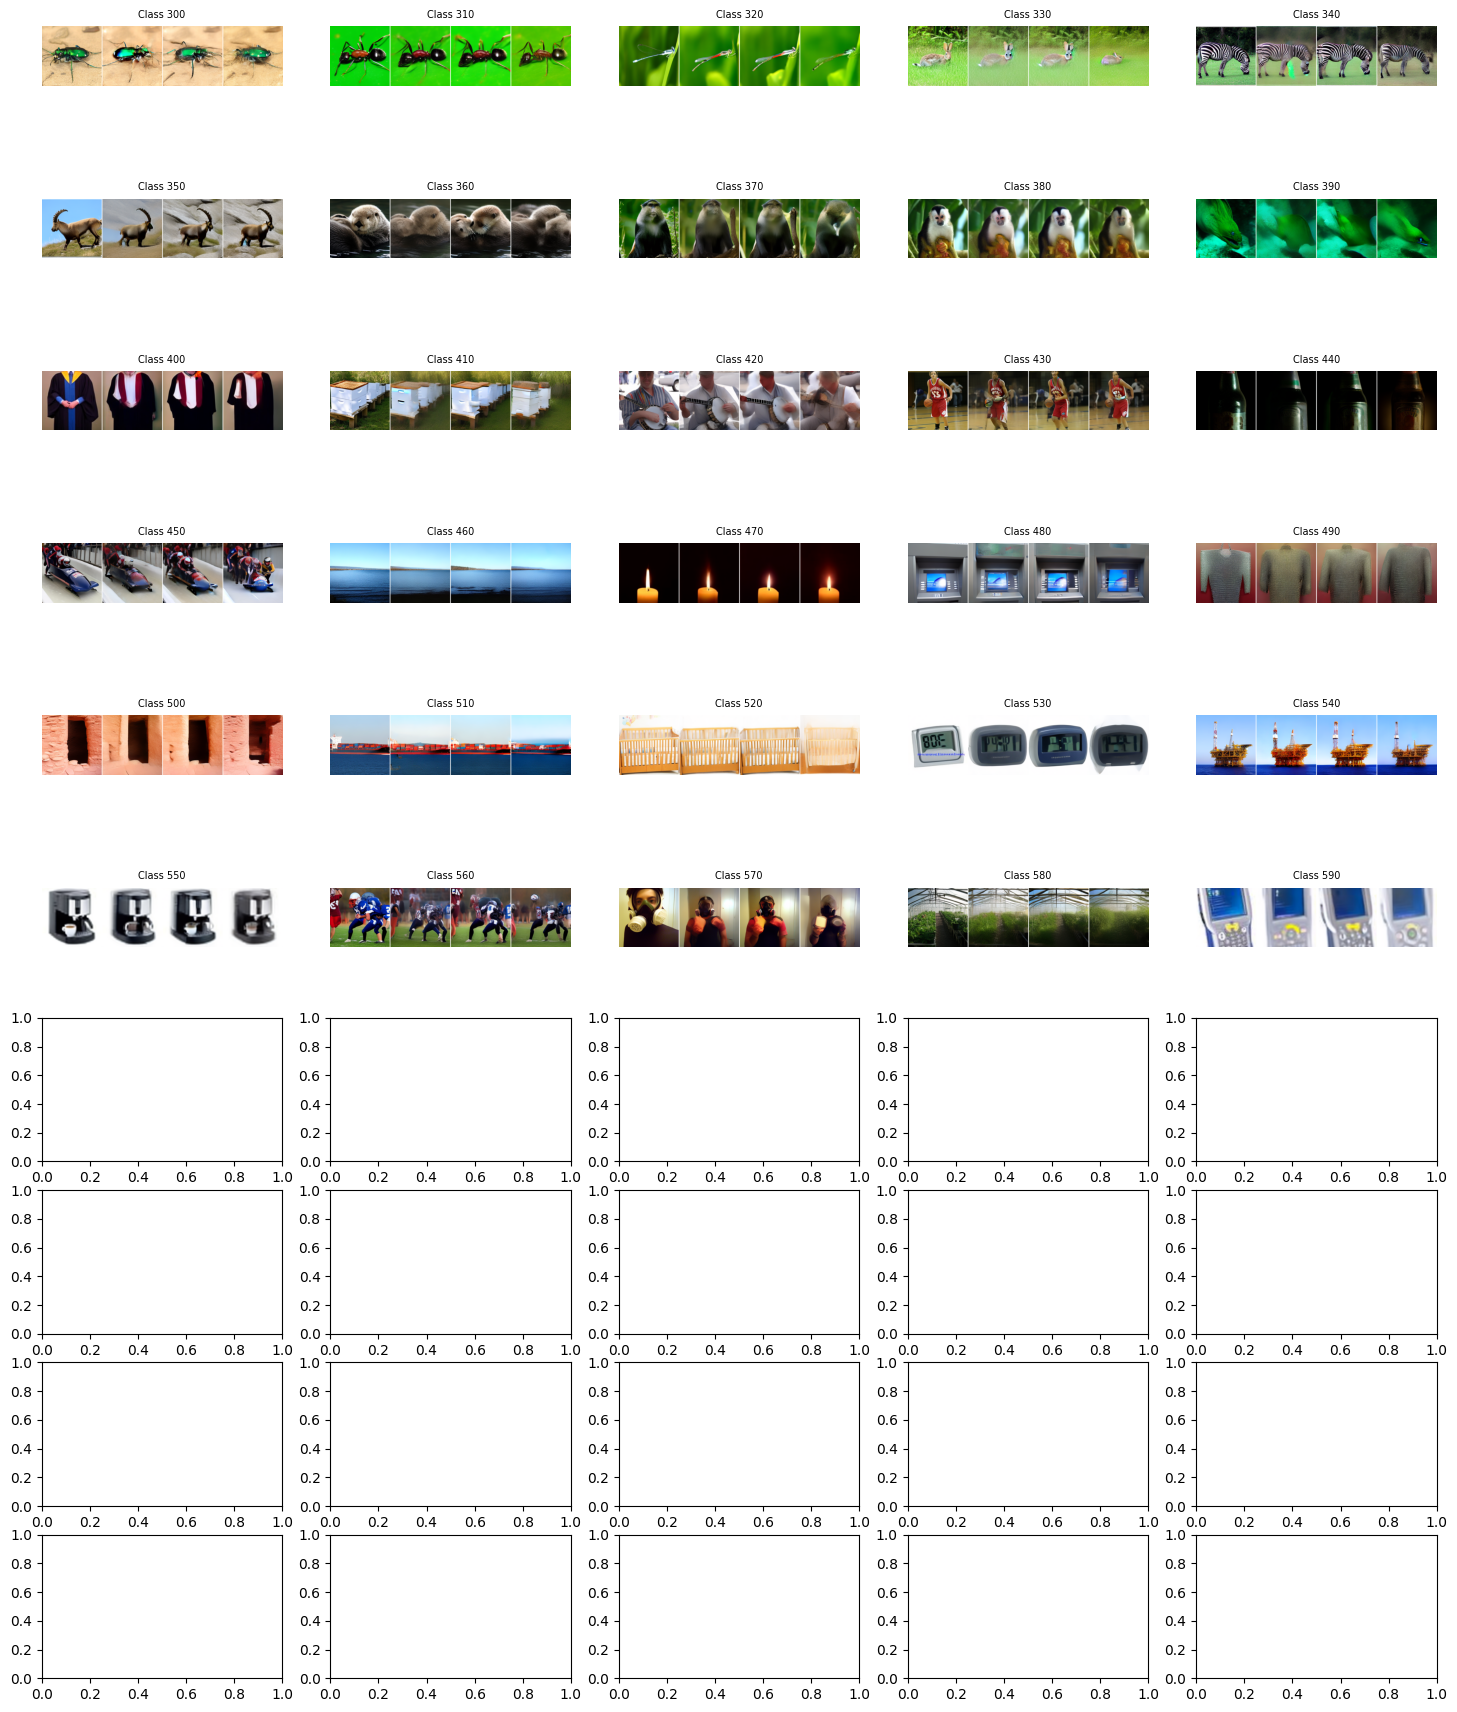

In [ ]:
import numpy as np, torch, matplotlib.pyplot as plt
from PIL import Image
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# ---- Config ----
cols, rows = 5, 10                 # 5x10 grid (50 classes)
assert cols * rows == 50
cls = list(range(300, 600, 10))     # 0..980 (50개)
CFG = 4.0
steps_e20, steps_g, steps_d, steps_e5 = 20, 5, 5, 5
skip, algo = "time_uniform", "data_prediction"
gdual_ckpt = 'logs/CFG4.0/0815-7:CLIP,pred,gap,quality/step_00000500.pt'

# ---- Utils ----
def u8(x):
    if isinstance(x, Image.Image): a = np.array(x)
    elif isinstance(x, torch.Tensor): a = x.detach().cpu().numpy()
    else: a = np.array(x)
    if a.ndim == 3 and a.shape[0] in (1,3): a = a.transpose(1,2,0)           # CHW->HWC
    if a.dtype != np.uint8:
        a = a.astype(np.float32); vmin, vmax = a.min(), a.max()
        if vmin < -1e-3 or vmax > 1+1e-3: a = (a - vmin) / (vmax - vmin + 1e-8)
        else: a = np.clip((a + 1)*0.5 if vmin < 0 else a, 0, 1)
        a = (a * 255 + 0.5).astype(np.uint8)
    if a.ndim == 2: a = np.stack([a]*3, -1)
    if a.shape[-1] == 1: a = np.repeat(a, 3, -1)
    return a

def decode_to_u8_list(x):
    xs = list(x) if not isinstance(x, torch.Tensor) else list(x)
    return [u8(im) for im in xs]

def hcat(*ims, sp=3):
    xs = [u8(i) for i in ims]; H = max(x.shape[0] for x in xs)
    def pad(I):
        t = (H - I.shape[0]) // 2; b = H - I.shape[0] - t
        return np.pad(I, ((t,b),(0,0),(0,0)), mode='constant', constant_values=255)
    xs = [pad(x) for x in xs]; gap = 255*np.ones((H, sp, 3), np.uint8)
    out = xs[0]
    for x in xs[1:]: out = np.concatenate([out, gap, x], 1)
    return out

# ---- Build model_fn & latents ----
ns = model.get_noise_schedule()
fn = model.get_model_fn(noise_schedule=ns, pos_conds=cls, guidance_scale=CFG)
z  = model.get_noise(seeds=cls)

# ---- Euler(20) ----
eul20 = Euler_Solver(ns, steps=steps_e20, skip_type=skip, algorithm_type=algo)
with torch.no_grad():
    e20_lat = eul20.sample(z, fn)
    e20_lat = e20_lat['samples'] if isinstance(e20_lat, dict) and 'samples' in e20_lat else e20_lat
    E20 = decode_to_u8_list(model.decode_vae(e20_lat))

# ---- GDual ----
from solvers.dual.dynamic.gdual_solver_log_deltaL_only import GDual_Solver
from solvers.transforms.loglinear_transform_general import LogLinearTransform
from solvers.param_extractors.gap_extractor import Extractor

noise_schedule = model.get_noise_schedule()
gdual = GDual_Solver(
    noise_schedule, steps=5, transform=LogLinearTransform(gamma_push=True, gamma_max=3, kappa_max=3, kappa_disable=False),
    param_extractor=Extractor(), skip_type="time_uniform", order=2, use_corrector=False, time_learning=True, train_mode=True
).to(model.device)
sd = torch.load(gdual_ckpt, map_location='cpu')
gdual.load_state_dict(sd.get('solver_state_dict', sd), strict=True)
with torch.no_grad():
    G = decode_to_u8_list(model.decode_vae(gdual.sample(z, fn)))

# ---- DPM ----
dpm = DPM_Solver(ns, algorithm_type=algo)
with torch.no_grad():
    D = decode_to_u8_list(model.decode_vae(dpm.sample(fn, z, steps=steps_d, skip_type=skip)))

# ---- Euler(5) ----
eul5 = Euler_Solver(ns, steps=steps_e5, skip_type=skip, algorithm_type=algo)
with torch.no_grad():
    e5_lat = eul5.sample(z, fn)
    e5_lat = e5_lat['samples'] if isinstance(e5_lat, dict) and 'samples' in e5_lat else e5_lat
    E5 = decode_to_u8_list(model.decode_vae(e5_lat))

# ---- Compose & Plot (Euler20 | GDual | DPM | Euler5) ----
tiles = [hcat(E20[i], G[i], D[i], E5[i]) for i in range(len(cls))]
fig, ax = plt.subplots(rows, cols, figsize=(cols*3.6, rows*2.2))
ax = ax.ravel()
for i,a in enumerate(ax):
    a.imshow(tiles[i]); a.set_title(f"Class {cls[i]}", fontsize=7); a.axis('off')
fig.suptitle(f"(Euler {steps_e20} | GDual {steps_g} | DPM {steps_d} | Euler {steps_e5}, CFG={CFG})", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()
